##  Setup and Imports

In [32]:
import sys
from pathlib import Path

# Add project root to path
project_root = Path().absolute().parent
sys.path.append(str(project_root))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings

# TensorFlow and Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

# Project imports
from config.config import Config
from src.data_loader import StockDataLoader
from src.data_preprocessor import StockDataPreprocessor
from src.model import LSTMStockModel
from src.trainer import ModelTrainer
from utils.helpers import split_train_val_test, save_scaler

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")
print(" Imports successful")

TensorFlow version: 2.19.0
GPU available: []
 Imports successful


##  Configuration

In [33]:
# Initialize configuration
config = Config()

# Display configuration

print("CONFIGURATION")

print(f"\nData Config:")
print(f"  - Raw data path: {config.data.raw_data_path}")
print(f"  - Target column: {config.data.target_column}")
print(f"  - Feature columns: {config.data.feature_columns}")

print(f"\nPreprocessing Config:")
print(f"  - Sequence length: {config.preprocessing.sequence_length}")
print(f"  - Train ratio: {config.preprocessing.train_ratio}")
print(f"  - Validation ratio: {config.preprocessing.validation_ratio}")
print(f"  - Test ratio: {config.preprocessing.test_ratio}")

print(f"\nModel Config:")
print(f"  - Model type: {config.model.model_type}")
print(f"  - LSTM units: {config.model.lstm_units}")
print(f"  - Dropout rate: {config.model.dropout_rate}")
print(f"  - Learning rate: {config.model.learning_rate}")

print(f"\nTraining Config:")
print(f"  - Epochs: {config.training.epochs}")
print(f"  - Batch size: {config.training.batch_size}")
print(f"  - Early stopping patience: {config.training.early_stopping_patience}")

CONFIGURATION

Data Config:
  - Raw data path: data/processed/lstm_ready_data.csv
  - Target column: Close
  - Feature columns: ['Open', 'High', 'Low', 'Close', 'Volume']

Preprocessing Config:
  - Sequence length: 12
  - Train ratio: 0.8
  - Validation ratio: 0.1
  - Test ratio: 0.1

Model Config:
  - Model type: stacked_lstm
  - LSTM units: [50, 50]
  - Dropout rate: 0.2
  - Learning rate: 0.001

Training Config:
  - Epochs: 100
  - Batch size: 32
  - Early stopping patience: 15


##  Load and Prepare Data

In [34]:
# Load data
data_path = project_root / config.data.raw_data_path
print(f"Loading data from: {data_path}")

data_loader = StockDataLoader(str(data_path))
df = data_loader.load_csv(date_column=config.data.date_column)

print(f"\n✓ Loaded {len(df):,} records")
print(f"✓ Columns: {list(df.columns)}")
print(f"✓ Date range: {df[config.data.date_column].min()} to {df[config.data.date_column].max()}")

df.head()

INFO:src.data_loader:Loaded 245 records from c:\Users\USER\OneDrive\Documents\GitHub\Research-Project\backend\lstm_stock_prediction\data\processed\lstm_ready_data.csv


Loading data from: c:\Users\USER\OneDrive\Documents\GitHub\Research-Project\backend\lstm_stock_prediction\data\processed\lstm_ready_data.csv

✓ Loaded 245 records
✓ Columns: ['Date', 'Open', 'High', 'Low', 'Close', 'Volume']
✓ Date range: 2000-01-01 00:00:00 to 2020-06-01 00:00:00


,Date,Open,High,Low,Close,Volume
0,2000-01-01,102.860335,43.043575,40.854469,102.860335,18412.0
1,2000-02-01,82.811518,40.917801,38.652880,82.827225,15820.0
2,2000-03-01,71.360406,34.579695,31.312690,71.375635,14061.0
3,2000-04-01,38.967033,33.376923,31.453846,39.368132,7165.0
4,2000-05-01,76.277778,36.832500,33.632778,76.477778,13766.0


In [35]:
# Preprocess data
preprocessor = StockDataPreprocessor(
    feature_columns=config.data.feature_columns,
    target_column=config.data.target_column
)

# Handle missing values
df = preprocessor.handle_missing_values(df, method=config.preprocessing.missing_value_method)

print(f" Preprocessed data shape: {df.shape}")
print(f" Missing values: {df.isnull().sum().sum()}")

 Preprocessed data shape: (245, 6)
 Missing values: 0


In [36]:
# --- DATA PREPROCESSING (Fixing Leakage & Scaling) ---
# We split the raw data first to ensure the scaler only learns from the training period

print("FEATURE SCALING (DATA LEAKAGE PREVENTION)")
print("=" * 70)

# Split the raw data first
train_idx = int(len(df) * config.preprocessing.train_ratio)
train_df = df.iloc[:train_idx]

print(f"\n Data Split (Before Scaling):")
print(f"  - Total records: {len(df):,}")
print(f"  - Training records: {len(train_df):,} ({len(train_df)/len(df)*100:.1f}%)")
print(f"  - Remaining (Val+Test): {len(df) - len(train_df):,}")

# Initialize and fit scalers ONLY on training data
feature_scaler = MinMaxScaler(feature_range=(0, 1))
target_scaler = MinMaxScaler(feature_range=(0, 1))

feature_scaler.fit(train_df[config.data.feature_columns])
target_scaler.fit(train_df[[config.data.target_column]])

print(f"\n Scalers fitted on TRAINING DATA ONLY to prevent leakage")

# Transform the entire dataset based on training parameters
scaled_features = feature_scaler.transform(df[config.data.feature_columns])
scaled_target = target_scaler.transform(df[[config.data.target_column]])

print(f"\n Scaled shapes:")
print(f"  - Scaled features: {scaled_features.shape}")
print(f"  - Scaled target: {scaled_target.shape}")

# Save scalers
scaler_dir = project_root / 'models' / 'scalers'
scaler_dir.mkdir(parents=True, exist_ok=True)

import joblib
joblib.dump(feature_scaler, scaler_dir / 'feature_scaler.pkl')
joblib.dump(target_scaler, scaler_dir / 'target_scaler.pkl')
print(f"\n Scalers saved to {scaler_dir}")

FEATURE SCALING (DATA LEAKAGE PREVENTION)

 Data Split (Before Scaling):
  - Total records: 245
  - Training records: 196 (80.0%)
  - Remaining (Val+Test): 49

 Scalers fitted on TRAINING DATA ONLY to prevent leakage

 Scaled shapes:
  - Scaled features: (245, 5)
  - Scaled target: (245, 1)

 Scalers saved to c:\Users\USER\OneDrive\Documents\GitHub\Research-Project\backend\lstm_stock_prediction\models\scalers


## Create Sequences

In [37]:
def create_sequences(features, target, sequence_length):
    """
    Create sequences for LSTM training.
    
    Args:
        features: Scaled feature array
        target: Scaled target array
        sequence_length: Number of time steps to look back
    
    Returns:
        X: Sequences of features (samples, sequence_length, n_features)
        y: Target values (samples, 1)
    """
    X, y = [], []
    
    for i in range(sequence_length, len(features)):
        X.append(features[i-sequence_length:i])
        y.append(target[i])
    
    return np.array(X), np.array(y)

# Create sequences
sequence_length = config.preprocessing.sequence_length
print(f"Creating sequences with length: {sequence_length}")

X, y = create_sequences(scaled_features, scaled_target, sequence_length)

print(f"\n Sequence shape: {X.shape}")
print(f" Target shape: {y.shape}")
print(f" Total samples: {len(X):,}")

# Validate data integrity
print(f"\n Data Integrity Checks:")
has_nan_X = np.isnan(X).any()
has_nan_y = np.isnan(y).any()
has_inf_X = np.isinf(X).any()
has_inf_y = np.isinf(y).any()

print(f"  - NaN in sequences: {' YES' if has_nan_X else '✓ NO'}")
print(f"  - NaN in targets: {' YES' if has_nan_y else '✓ NO'}")
print(f"  - Inf in sequences: {' YES' if has_inf_X else '✓ NO'}")
print(f"  - Inf in targets: {' YES' if has_inf_y else '✓ NO'}")

if has_nan_X or has_nan_y or has_inf_X or has_inf_y:
    print("\n")
    print("This will cause training to fail. Please check your data preprocessing.")
else:
    print("\ All data integrity checks passed!")

Creating sequences with length: 12

 Sequence shape: (233, 12, 5)
 Target shape: (233, 1)
 Total samples: 233

 Data Integrity Checks:
  - NaN in sequences: ✓ NO
  - NaN in targets: ✓ NO
  - Inf in sequences: ✓ NO
  - Inf in targets: ✓ NO
\ All data integrity checks passed!


## Split Data

In [38]:
# Split into train, validation, and test sets
train_size = int(len(X) * config.preprocessing.train_ratio)
val_size = int(len(X) * config.preprocessing.validation_ratio)

X_train = X[:train_size]
y_train = y[:train_size]

X_val = X[train_size:train_size+val_size]
y_val = y[train_size:train_size+val_size]

X_test = X[train_size+val_size:]
y_test = y[train_size+val_size:]


print("DATA SPLIT")

print(f"\nTraining set:")
print(f"  - X_train shape: {X_train.shape}")
print(f"  - y_train shape: {y_train.shape}")
print(f"  - Samples: {len(X_train):,} ({len(X_train)/len(X)*100:.1f}%)")

print(f"\nValidation set:")
print(f"  - X_val shape: {X_val.shape}")
print(f"  - y_val shape: {y_val.shape}")
print(f"  - Samples: {len(X_val):,} ({len(X_val)/len(X)*100:.1f}%)")

print(f"\nTest set:")
print(f"  - X_test shape: {X_test.shape}")
print(f"  - y_test shape: {y_test.shape}")
print(f"  - Samples: {len(X_test):,} ({len(X_test)/len(X)*100:.1f}%)")

DATA SPLIT

Training set:
  - X_train shape: (186, 12, 5)
  - y_train shape: (186, 1)
  - Samples: 186 (79.8%)

Validation set:
  - X_val shape: (23, 12, 5)
  - y_val shape: (23, 1)
  - Samples: 23 (9.9%)

Test set:
  - X_test shape: (24, 12, 5)
  - y_test shape: (24, 1)
  - Samples: 24 (10.3%)


##  Build Model

In [39]:
# Input shape
input_shape = (X_train.shape[1], X_train.shape[2])
print(f"Input shape: {input_shape}")

# Build model
lstm_model_builder = LSTMStockModel(input_shape=input_shape)

# Choose model architecture based on config
if config.model.model_type == 'simple_lstm':
    model = lstm_model_builder.build_simple_lstm(
        units=config.model.lstm_units[0],
        dropout=config.model.dropout_rate
    )
elif config.model.model_type == 'stacked_lstm':
    model = lstm_model_builder.build_stacked_lstm(
        units=config.model.lstm_units,
        dropout=config.model.dropout_rate
    )
elif config.model.model_type == 'bidirectional_lstm':
    model = lstm_model_builder.build_bidirectional_lstm(
        units=config.model.lstm_units,
        dropout=config.model.dropout_rate
    )
else:
    print(f"Unknown model type: {config.model.model_type}")
    print("Using stacked LSTM as default")
    model = lstm_model_builder.build_stacked_lstm(
        units=config.model.lstm_units,
        dropout=config.model.dropout_rate
    )

# Compile model (Fixed: Using Huber Loss for Stability)
# Huber loss handles outliers better than MSE for stock price spikes
# MAPE removed from training metrics because it's mathematically broken on [0,1] scaled data
optimizer = keras.optimizers.Adam(learning_rate=config.model.learning_rate)
model.compile(
    optimizer=optimizer,
    loss='huber',  # Changed from MSE to Huber for better stability
    metrics=['mae']  # Removed MAPE - will calculate on real prices later
)


print("MODEL ARCHITECTURE")
print("Loss Function: Huber Loss (robust to outliers)")
print("Metrics: MAE (MAPE will be calculated on original price scale)")
model.summary()

Input shape: (12, 5)


INFO:src.model:Built stacked LSTM model with layers: [50, 50]


MODEL ARCHITECTURE
Loss Function: Huber Loss (robust to outliers)
Metrics: MAE (MAPE will be calculated on original price scale)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 12, 50)         │        11,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 12, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,451 (122.86 KB)

 Trainable params: 31,451 (122.86 KB)

 Non-trainable params: 0 (0.00 B)

##  Setup Callbacks

In [40]:
# Create directories
model_dir = project_root / 'models' / 'saved_models'
checkpoint_dir = project_root / 'models' / 'checkpoints'
log_dir = project_root / 'logs' / f'training_{datetime.now().strftime("%Y%m%d_%H%M%S")}'

model_dir.mkdir(parents=True, exist_ok=True)
checkpoint_dir.mkdir(parents=True, exist_ok=True)
log_dir.mkdir(parents=True, exist_ok=True)

# Define callbacks
callback_list = [
    # Early stopping
    callbacks.EarlyStopping(
        monitor='val_loss',
        patience=config.training.early_stopping_patience,
        restore_best_weights=True,
        verbose=1
    ),
    
    # Model checkpoint
    callbacks.ModelCheckpoint(
        filepath=str(checkpoint_dir / 'model_epoch_{epoch:02d}_valloss_{val_loss:.4f}.keras'),
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    ),
    
    # Reduce learning rate
    callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=config.training.reduce_lr_patience,
        min_lr=1e-7,
        verbose=1
    ),
    
    # TensorBoard
    callbacks.TensorBoard(
        log_dir=str(log_dir),
        histogram_freq=1
    ),
    
    # CSV Logger
    callbacks.CSVLogger(
        filename=str(log_dir / 'training_log.csv'),
        separator=',',
        append=False
    )
]

print(" Callbacks configured")
print(f"  - Model checkpoints: {checkpoint_dir}")
print(f"  - Training logs: {log_dir}")

 Callbacks configured
  - Model checkpoints: c:\Users\USER\OneDrive\Documents\GitHub\Research-Project\backend\lstm_stock_prediction\models\checkpoints
  - Training logs: c:\Users\USER\OneDrive\Documents\GitHub\Research-Project\backend\lstm_stock_prediction\logs\training_20260301_144618


In [41]:
# Train the model

# Pre-training validation

print("PRE-TRAINING VALIDATION")


# Check data integrity
print("\n Data Validation:")
print(f"  ✓ Training samples: {len(X_train):,}")
print(f"  ✓ Validation samples: {len(X_val):,}")
print(f"  ✓ Training data shape: {X_train.shape}")
print(f"  ✓ No NaN in X_train: {not np.isnan(X_train).any()}")
print(f"  ✓ No NaN in y_train: {not np.isnan(y_train).any()}")
print(f"  ✓ No Inf in X_train: {not np.isinf(X_train).any()}")
print(f"  ✓ No Inf in y_train: {not np.isinf(y_train).any()}")

# Memory check
print(f"\n Memory Usage:")
print(f"  - X_train size: {X_train.nbytes / 1024**2:.2f} MB")
print(f"  - y_train size: {y_train.nbytes / 1024**2:.2f} MB")
print(f"  - Model parameters: {model.count_params():,}")

# GPU check
if len(tf.config.list_physical_devices('GPU')) > 0:
    print(f"\n GPU Configuration:")
    try:
        # Prevent GPU memory overflow
        gpus = tf.config.list_physical_devices('GPU')
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"  ✓ GPU memory growth enabled")
    except Exception as e:
        print(f"  ⚠ GPU configuration warning: {e}")

# Training configuration
print("STARTING TRAINING")

print(f"Epochs: {config.training.epochs}")
print(f"Batch size: {config.training.batch_size}")
print(f"Training started at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")

try:
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=config.training.epochs,
        batch_size=config.training.batch_size,
        callbacks=callback_list,
        verbose=1,
        shuffle=config.training.shuffle
    )
    
    print(f"\n✓ Training completed at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    
except Exception as e:
    print(f"\n Training failed with error:")
    print(f"Error type: {type(e).__name__}")
    print(f"Error message: {str(e)}")
    print("\n Troubleshooting suggestions:")
    print("  1. Reduce batch_size in config (try 16 or 8)")
    print("  2. Reduce epochs (try 10-20 for testing)")
    print("  3. If GPU memory error: Restart kernel")
    print("  4. Check if data contains NaN or Inf values")
    print("  5. Try running with fewer samples first")
    raise

PRE-TRAINING VALIDATION

 Data Validation:
  ✓ Training samples: 186
  ✓ Validation samples: 23
  ✓ Training data shape: (186, 12, 5)
  ✓ No NaN in X_train: True
  ✓ No NaN in y_train: True
  ✓ No Inf in X_train: True
  ✓ No Inf in y_train: True

 Memory Usage:
  - X_train size: 0.09 MB
  - y_train size: 0.00 MB
  - Model parameters: 31,451
STARTING TRAINING
Epochs: 100
Batch size: 32
Training started at: 2026-03-01 14:46:18

Epoch 1/100
1/6 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - loss: 0.0013 - mae: 0.0413
Epoch 1: val_loss improved from None to 0.00966, saving model to c:\Users\USER\OneDrive\Documents\GitHub\Research-Project\backend\lstm_stock_prediction\models\checkpoints\model_epoch_01_valloss_0.0097.keras
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 111ms/step - loss: 0.0170 - mae: 0.1230 - val_loss: 0.0097 - val_mae: 0.1335 - learning_rate: 0.0010
Epoch 2/100
1/6 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0023 - mae: 0.0627
Epoch 2: val_loss did not improve from 0.00966
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 32

## 10. Save Model

In [42]:
# Save the final model
model_save_path = model_dir / f'lstm_model_{datetime.now().strftime("%Y%m%d_%H%M%S")}.keras'
model.save(model_save_path)
print(f" Model saved to: {model_save_path}")

# Save training history
history_df = pd.DataFrame(history.history)
history_csv_path = log_dir / 'training_history.csv'
history_df.to_csv(history_csv_path, index=False)
print(f" Training history saved to: {history_csv_path}")

 Model saved to: c:\Users\USER\OneDrive\Documents\GitHub\Research-Project\backend\lstm_stock_prediction\models\saved_models\lstm_model_20260301_144625.keras
 Training history saved to: c:\Users\USER\OneDrive\Documents\GitHub\Research-Project\backend\lstm_stock_prediction\logs\training_20260301_144618\training_history.csv


## 11. Visualize Training History

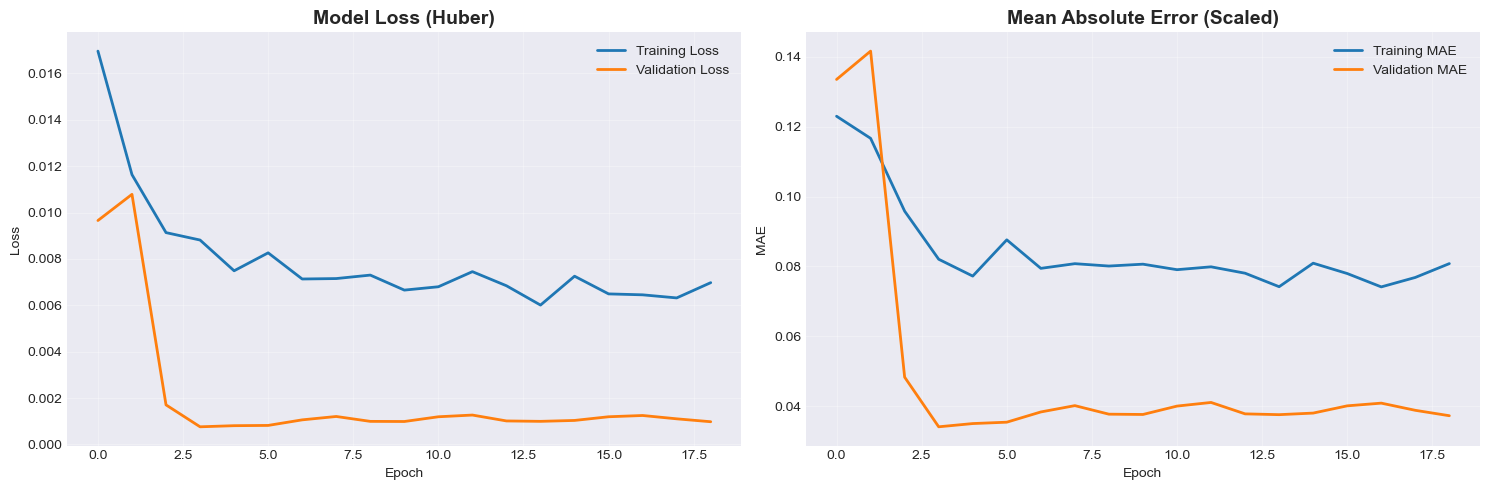

 Training plots saved to: c:\Users\USER\OneDrive\Documents\GitHub\Research-Project\backend\lstm_stock_prediction\logs\training_20260301_144618\training_history.png

Note: MAE shown is on scaled [0,1] data. Real-world metrics calculated below.


In [43]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Loss
axes[0].plot(history.history['loss'], label='Training Loss', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
axes[0].set_title('Model Loss (Huber)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# MAE
axes[1].plot(history.history['mae'], label='Training MAE', linewidth=2)
axes[1].plot(history.history['val_mae'], label='Validation MAE', linewidth=2)
axes[1].set_title('Mean Absolute Error (Scaled)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(log_dir / 'training_history.png', dpi=300, bbox_inches='tight')
plt.show()

print(f" Training plots saved to: {log_dir / 'training_history.png'}")
print("\nNote: MAE shown is on scaled [0,1] data. Real-world metrics calculated below.")

## 12. Training Summary

In [44]:
# Display training summary

# Check if model has been trained
if 'history' not in locals():
    print(" Error: Model has not been trained yet!")
    print("Please run the training cell before running this cell.")
    raise NameError("'history' is not defined. Please train the model first.")

print("TRAINING SUMMARY")
print("=" * 70)

final_epoch = len(history.history['loss'])
final_train_loss = history.history['loss'][-1]
final_val_loss = history.history['val_loss'][-1]
final_train_mae = history.history['mae'][-1]
final_val_mae = history.history['val_mae'][-1]

best_val_loss = min(history.history['val_loss'])
best_epoch = history.history['val_loss'].index(best_val_loss) + 1

print(f"\n Training Configuration:")
print(f"  - Model Type: {config.model.model_type}")
print(f"  - LSTM Units: {config.model.lstm_units}")
print(f"  - Sequence Length: {config.preprocessing.sequence_length}")
print(f"  - Total Epochs Trained: {final_epoch}")
print(f"  - Batch Size: {config.training.batch_size}")
print(f"  - Loss Function: Huber Loss (robust to outliers)")

print(f"\n Final Metrics (Epoch {final_epoch}) - ON SCALED DATA:")
print(f"  - Training Loss: {final_train_loss:.6f}")
print(f"  - Validation Loss: {final_val_loss:.6f}")
print(f"  - Training MAE: {final_train_mae:.6f}")
print(f"  - Validation MAE: {final_val_mae:.6f}")

print(f"\n Best Performance:")
print(f"  - Best Validation Loss: {best_val_loss:.6f}")
print(f"  - Best Epoch: {best_epoch}")

print(f"\n Saved Artifacts:")
print(f"  - Model: {model_save_path}")
print(f"  - Training History: {history_csv_path}")
print(f"  - Plots: {log_dir}")
print(f"  - Scalers: {scaler_dir}")

print("\n Real-world metrics (MAE, MAPE on original prices) calculated in next cell...")
print(" Model training completed successfully!")

TRAINING SUMMARY

 Training Configuration:
  - Model Type: stacked_lstm
  - LSTM Units: [50, 50]
  - Sequence Length: 12
  - Total Epochs Trained: 19
  - Batch Size: 32
  - Loss Function: Huber Loss (robust to outliers)

 Final Metrics (Epoch 19) - ON SCALED DATA:
  - Training Loss: 0.006976
  - Validation Loss: 0.000980
  - Training MAE: 0.080827
  - Validation MAE: 0.037332

 Best Performance:
  - Best Validation Loss: 0.000762
  - Best Epoch: 4

 Saved Artifacts:
  - Model: c:\Users\USER\OneDrive\Documents\GitHub\Research-Project\backend\lstm_stock_prediction\models\saved_models\lstm_model_20260301_144625.keras
  - Training History: c:\Users\USER\OneDrive\Documents\GitHub\Research-Project\backend\lstm_stock_prediction\logs\training_20260301_144618\training_history.csv
  - Plots: c:\Users\USER\OneDrive\Documents\GitHub\Research-Project\backend\lstm_stock_prediction\logs\training_20260301_144618
  - Scalers: c:\Users\USER\OneDrive\Documents\GitHub\Research-Project\backend\lstm_stock_p

## 13. Real-World Performance Evaluation (MAPE FIX)

**THE MAPE FIX:** Calculate metrics on original price scale (not scaled [0,1] data).
This prevents MAPE explosion and gives accurate real-world performance metrics.

CORRECTED PERFORMANCE METRICS (Original Price Scale)

Calculating real-world performance on original price scale...
This prevents the MAPE explosion caused by scaled [0,1] data.

 REAL-WORLD METRICS (on original price scale):

Training Set:
  - MAE:  178.63 Rs.
  - MAPE: 61.89%

Validation Set:
  - MAE:  80.07 Rs.
  - MAPE: 32.12%

Test Set:
  - MAE:  108.13 Rs.
  - MAPE: 29.56%

Additional Test Set Metrics:
  - RMSE: 148.07 Rs.
  - R² Score: 0.0475

✓ Real-world performance evaluation completed!

These metrics are calculated on the ORIGINAL PRICE SCALE,
making them accurate and interpretable for business decisions.


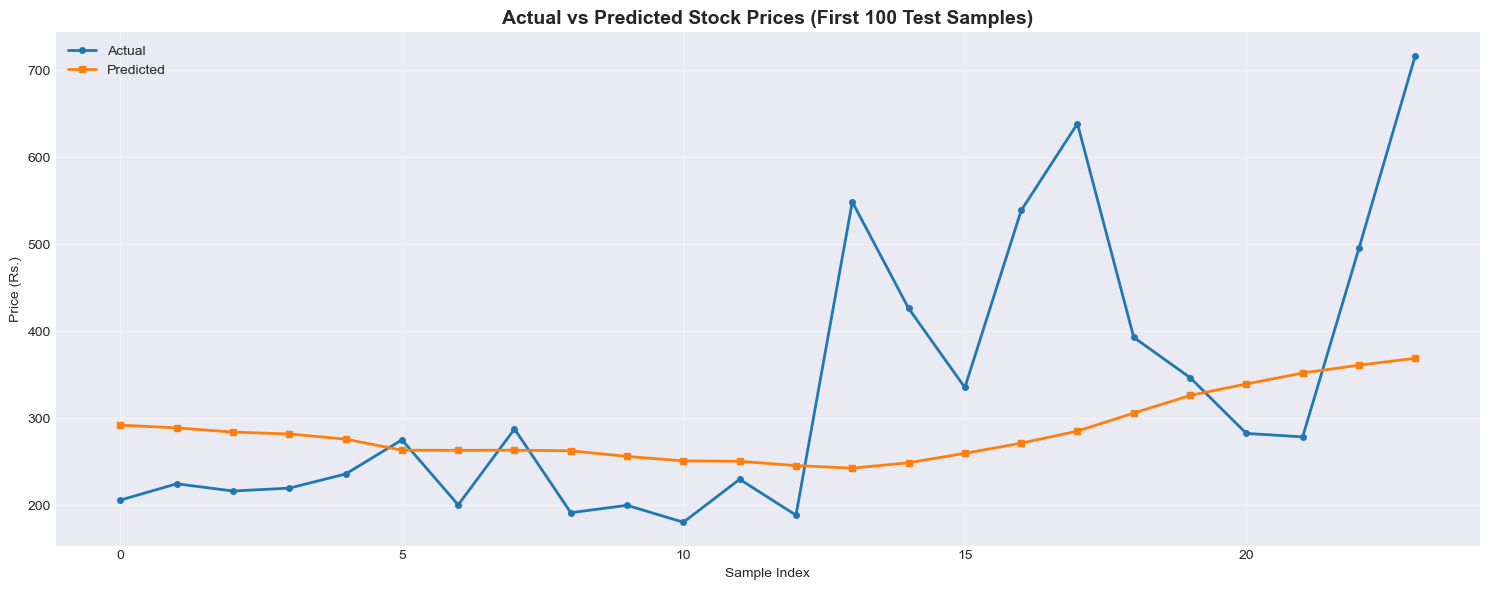


 Prediction plot saved to: c:\Users\USER\OneDrive\Documents\GitHub\Research-Project\backend\lstm_stock_prediction\logs\training_20260301_144618\real_world_predictions.png


In [45]:
# --- THE MAPE FIX (Calculate on Real Prices) ---
def get_real_world_performance(model, X_data, y_true_scaled, scaler):
    """
    Inverse transforms the data back to original currency scale 
    before calculating errors. This stops the MAPE explosion.
    
    Args:
        model: Trained model
        X_data: Input sequences
        y_true_scaled: True target values (scaled [0,1])
        scaler: Target scaler to inverse transform
    
    Returns:
        mae: Mean Absolute Error on original scale
        mape: Mean Absolute Percentage Error on original scale
    """
    preds_scaled = model.predict(X_data, verbose=0)
    
    # Reshape and Inverse Transform to get actual prices
    y_true = scaler.inverse_transform(y_true_scaled.reshape(-1, 1))
    y_pred = scaler.inverse_transform(preds_scaled)
    
    # Calculate real-world metrics
    mae = np.mean(np.abs(y_true - y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    
    return mae, mape, y_true, y_pred

# Check if required variables exist
if 'model' not in locals():
    print(" Error: Model has not been trained yet!")
    raise NameError("'model' is not defined. Please train the model first.")

if 'X_train' not in locals() or 'X_val' not in locals() or 'X_test' not in locals():
    print(" Error: Data has not been prepared!")
    raise NameError("Data is not defined. Please prepare the data first.")

print("CORRECTED PERFORMANCE METRICS (Original Price Scale)")
print("=" * 70)
print("\nCalculating real-world performance on original price scale...")
print("This prevents the MAPE explosion caused by scaled [0,1] data.\n")

# Evaluate real performance on all sets
train_mae_real, train_mape_real, y_train_real, y_train_pred_real = get_real_world_performance(
    model, X_train, y_train, target_scaler
)
val_mae_real, val_mape_real, y_val_real, y_val_pred_real = get_real_world_performance(
    model, X_val, y_val, target_scaler
)
test_mae_real, test_mape_real, y_test_real, y_test_pred_real = get_real_world_performance(
    model, X_test, y_test, target_scaler
)

print(f" REAL-WORLD METRICS (on original price scale):")
print(f"\nTraining Set:")
print(f"  - MAE:  {train_mae_real:.2f} Rs.")
print(f"  - MAPE: {train_mape_real:.2f}%")

print(f"\nValidation Set:")
print(f"  - MAE:  {val_mae_real:.2f} Rs.")
print(f"  - MAPE: {val_mape_real:.2f}%")

print(f"\nTest Set:")
print(f"  - MAE:  {test_mae_real:.2f} Rs.")
print(f"  - MAPE: {test_mape_real:.2f}%")

# Additional metrics for test set
from sklearn.metrics import r2_score
test_r2 = r2_score(y_test_real, y_test_pred_real)
test_rmse = np.sqrt(np.mean((y_test_real - y_test_pred_real)**2))

print(f"\nAdditional Test Set Metrics:")
print(f"  - RMSE: {test_rmse:.2f} Rs.")
print(f"  - R² Score: {test_r2:.4f}")

print("\n✓ Real-world performance evaluation completed!")
print("\nThese metrics are calculated on the ORIGINAL PRICE SCALE,")
print("making them accurate and interpretable for business decisions.")

# Plot predictions vs actual
plt.figure(figsize=(15, 6))
plt.plot(y_test_real[:100], label='Actual', marker='o', markersize=4, linewidth=2)
plt.plot(y_test_pred_real[:100], label='Predicted', marker='s', markersize=4, linewidth=2)
plt.title('Actual vs Predicted Stock Prices (First 100 Test Samples)', fontsize=14, fontweight='bold')
plt.xlabel('Sample Index')
plt.ylabel('Price (Rs.)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(log_dir / 'real_world_predictions.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n Prediction plot saved to: {log_dir / 'real_world_predictions.png'}")